## Remnant models: final mass, spin, and kick

- **HLZ kick (precessing)** : precessing kick velocity from Gonzalez et al. (2007), Campanelli et al. (2007), Lousto & Zlochower (2008, 2013)
- **HLZ kick (aligned-spin)** : aligned-spin kick from arXiv:1406.7295
- **HBR final mass** : Barausse, Morozova & Rezzolla (2012), ApJ 758, 63
- **HBR final spin** : Hofmann, Barausse & Rezzolla (2016), ApJL 825, L19
- **UIB2016 final mass & spin** : Jimenez Forteza, Keitel, Husa et al. [arXiv:1611.00332]

In [1]:
import sys
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### 1. HLZ precessing kick velocity

In [2]:
# Equal mass, anti-aligned spins
q = 1.25
a1, a2 = 0.7, 0.7
theta1, theta2 = np.pi/4, 3*np.pi/4
delta_phi = np.pi

vk = gwModels.remnants.bbh_final_kick_precessing_CLZM2007(
    q, a1, a2, theta1, theta2, delta_phi, Theta=0.0)
print(f'Kick velocity: {vk:.2f} km/s')

Kick velocity: 2000.46 km/s


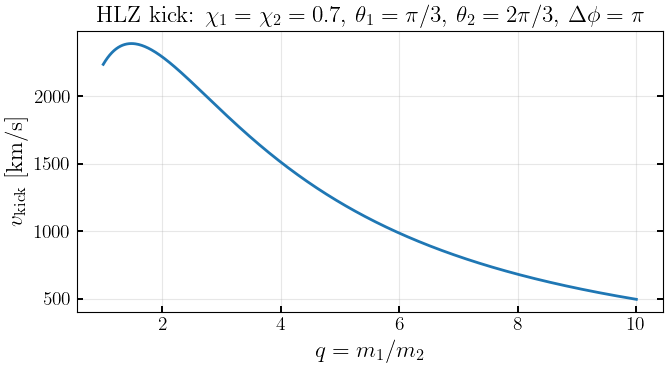

In [3]:
# Kick vs mass ratio for fixed spin configuration
q_arr = np.linspace(1.0, 10.0, 500)
a1, a2 = 0.7, 0.7
theta1, theta2 = np.pi/3, 2*np.pi/3
delta_phi = np.pi

vk_arr = np.array([gwModels.remnants.bbh_final_kick_precessing_CLZM2007(
    qq, a1, a2, theta1, theta2, delta_phi, Theta=0.0) for qq in q_arr])

plt.figure(figsize=(7, 4))
plt.plot(q_arr, vk_arr, lw=2)
plt.xlabel('$q = m_1/m_2$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.title(r'HLZ kick: $\chi_1=\chi_2=0.7$, $\theta_1=\pi/3$, $\theta_2=2\pi/3$, $\Delta\phi=\pi$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. HLZ aligned-spin kick (arXiv:1406.7295)

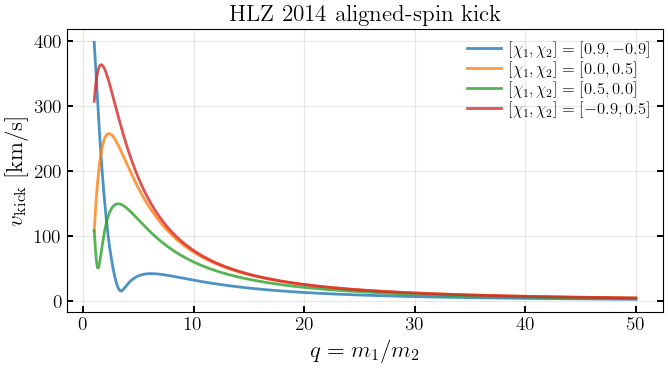

In [4]:
q_arr = np.linspace(1, 50, 500)

plt.figure(figsize=(7, 4))
for chi1z, chi2z, label in [
    (0.9, -0.9, r'$[\chi_1,\chi_2]=[0.9,-0.9]$'),
    (0.0, 0.5,  r'$[\chi_1,\chi_2]=[0.0,0.5]$'),
    (0.5, 0.0,  r'$[\chi_1,\chi_2]=[0.5,0.0]$'),
    (-0.9, 0.5, r'$[\chi_1,\chi_2]=[-0.9,0.5]$'),
]:
    vk = gwModels.remnants.bbh_final_kick_nonprecessing_HLZ2014(q_arr, chi1z, chi2z)
    plt.plot(q_arr, vk, lw=2, alpha=0.8, label=label)

plt.xlabel('$q = m_1/m_2$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.title('HLZ 2014 aligned-spin kick')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3. HBR final mass (Barausse, Morozova & Rezzolla 2012)

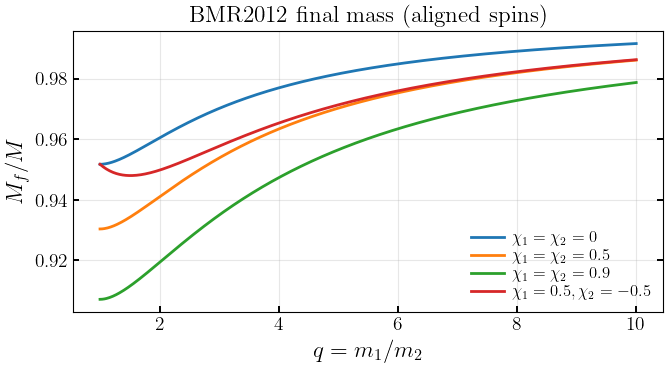

In [5]:
q_arr = np.linspace(1.0, 10.0, 500)

plt.figure(figsize=(7, 4))
for a1, a2, label in [
    (0.0, 0.0, r'$\chi_1=\chi_2=0$'),
    (0.5, 0.5, r'$\chi_1=\chi_2=0.5$'),
    (0.9, 0.9, r'$\chi_1=\chi_2=0.9$'),
    (0.5, -0.5, r'$\chi_1=0.5, \chi_2=-0.5$'),
]:
    mf = gwModels.remnants.bbh_final_mass_precessing_BMR2012(
        q=q_arr, a1=a1, a2=a2, theta1=0.0, theta2=0.0)
    plt.plot(q_arr, mf, lw=2, label=label)

plt.xlabel('$q = m_1/m_2$')
plt.ylabel('$M_f / M$')
plt.title('BMR2012 final mass (aligned spins)')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. HBR final spin (Hofmann, Barausse & Rezzolla 2016)

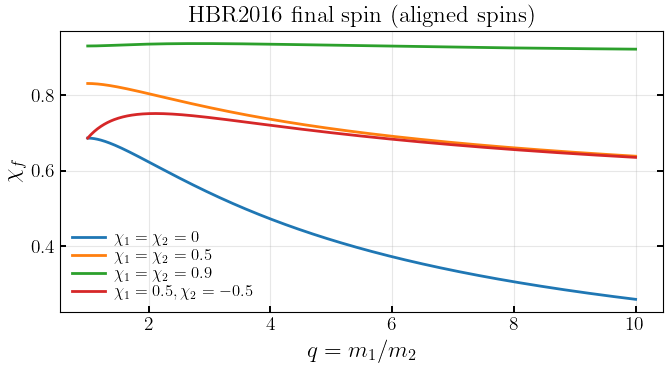

In [6]:
q_arr = np.linspace(1.0, 10.0, 500)

plt.figure(figsize=(7, 4))
for a1, a2, label in [
    (0.0, 0.0, r'$\chi_1=\chi_2=0$'),
    (0.5, 0.5, r'$\chi_1=\chi_2=0.5$'),
    (0.9, 0.9, r'$\chi_1=\chi_2=0.9$'),
    (0.5, -0.5, r'$\chi_1=0.5, \chi_2=-0.5$'),
]:
    sf = gwModels.remnants.bbh_final_spin_precessing_HBR2016(
        q=q_arr, a1=a1, a2=a2, theta1=0.0, theta2=0.0, delta_phi=0.0)
    plt.plot(q_arr, sf, lw=2, label=label)

plt.xlabel('$q = m_1/m_2$')
plt.ylabel('$\\chi_f$')
plt.title('HBR2016 final spin (aligned spins)')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5. UIB2016 final mass and spin (aligned-spin, Jimenez Forteza et al.)

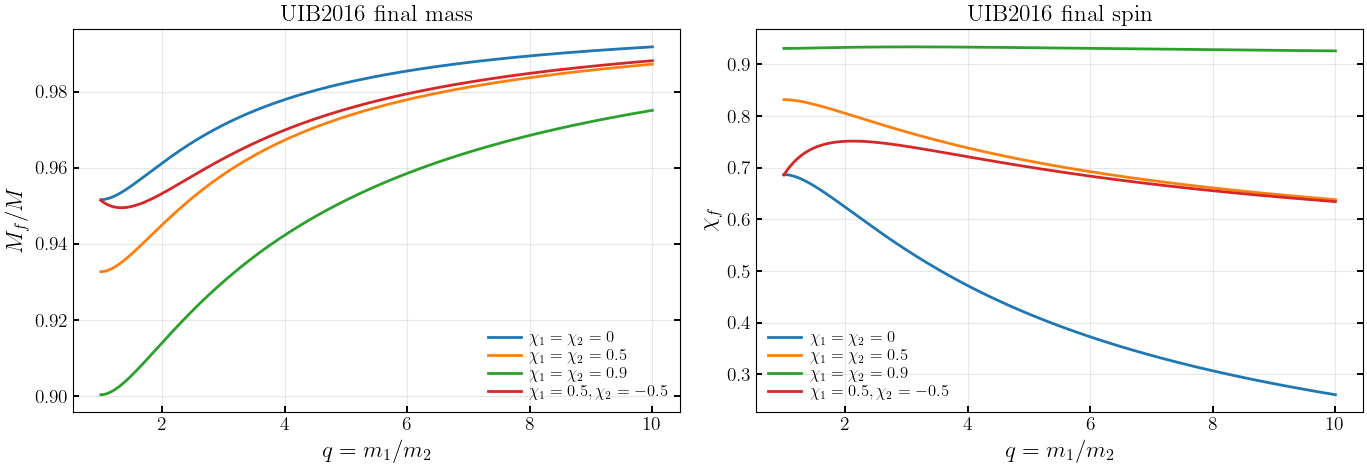

In [7]:
q_arr = np.linspace(1.0, 10.0, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for a1, a2, label in [
    (0.0, 0.0, r"$\chi_1=\chi_2=0$"),
    (0.5, 0.5, r"$\chi_1=\chi_2=0.5$"),
    (0.9, 0.9, r"$\chi_1=\chi_2=0.9$"),
    (0.5, -0.5, r"$\chi_1=0.5, \chi_2=-0.5$"),
]:
    mf = gwModels.remnants.bbh_final_mass_non_precessing_UIB2016(q_arr, a1, a2)
    sf = gwModels.remnants.bbh_final_spin_non_precessing_UIB2016(q_arr, a1, a2)
    axes[0].plot(q_arr, mf, lw=2, label=label)
    axes[1].plot(q_arr, sf, lw=2, label=label)

axes[0].set_xlabel('$q = m_1/m_2$')
axes[0].set_ylabel('$M_f / M$')
axes[0].set_title('UIB2016 final mass')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('$q = m_1/m_2$')
axes[1].set_ylabel('$\chi_f$')
axes[1].set_title('UIB2016 final spin')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()